In [2]:
import sys
import os

# Get the absolute path of 'src' dynamically
src_path = os.path.abspath(os.path.join(os.getcwd(), ".."))  

# Add 'src' to sys.path
sys.path.append(src_path)

# Verify that 'src' is in sys.path
print(sys.path)

['c:\\Users\\NAMAN\\Desktop\\kaggle_comp\\src\\notebooks', 'c:\\ProgramData\\anaconda3\\python311.zip', 'c:\\ProgramData\\anaconda3\\DLLs', 'c:\\ProgramData\\anaconda3\\Lib', 'c:\\ProgramData\\anaconda3', '', 'c:\\ProgramData\\anaconda3\\Lib\\site-packages', 'c:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32', 'c:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32\\lib', 'c:\\ProgramData\\anaconda3\\Lib\\site-packages\\Pythonwin', 'c:\\ProgramData\\anaconda3\\Lib\\site-packages\\setuptools\\_vendor', 'c:\\Users\\NAMAN\\Desktop\\kaggle_comp\\src']


In [3]:
from Backpack_Prediction_Challenge.exceptions import exception_handler
from Backpack_Prediction_Challenge.logger import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


step no 1) Importing data :-

In [4]:
train_df = pd.read_csv(r'C:\Users\NAMAN\Desktop\kaggle_comp\src\notebooks\data\Train_data.csv')
test_df = pd.read_csv(r'C:\Users\NAMAN\Desktop\kaggle_comp\src\notebooks\data\Test_data.csv')
extra_df = pd.read_csv(r'C:\Users\NAMAN\Desktop\kaggle_comp\src\notebooks\data\Extra_data.csv')

In [5]:
train_df.shape, test_df.shape, extra_df.shape

((300000, 11), (200000, 10), (1048575, 11))

In [6]:
(train_df.head(3))

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2,Yes,No,Messenger,Red,16.643760,39.17320


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    300000 non-null  int64  
 1   Brand                 290295 non-null  object 
 2   Material              291653 non-null  object 
 3   Size                  293405 non-null  object 
 4   Compartments          300000 non-null  int64  
 5   Laptop Compartment    292556 non-null  object 
 6   Waterproof            292950 non-null  object 
 7   Style                 292030 non-null  object 
 8   Color                 290050 non-null  object 
 9   Weight Capacity (kg)  299862 non-null  float64
 10  Price                 300000 non-null  float64
dtypes: float64(2), int64(2), object(7)
memory usage: 25.2+ MB


In [8]:
train_df.isna().sum()

id                         0
Brand                   9705
Material                8347
Size                    6595
Compartments               0
Laptop Compartment      7444
Waterproof              7050
Style                   7970
Color                   9950
Weight Capacity (kg)     138
Price                      0
dtype: int64

In [9]:
train_categorical_df = train_df.select_dtypes(include='object')
for col in train_categorical_df.columns:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)
train_df.isna().sum()

id                        0
Brand                     0
Material                  0
Size                      0
Compartments              0
Laptop Compartment        0
Waterproof                0
Style                     0
Color                     0
Weight Capacity (kg)    138
Price                     0
dtype: int64

In [10]:
train_numerical_df = train_df.select_dtypes(include=['int64', 'float64'])
for col in train_numerical_df.columns:
    train_df[col].fillna(train_df[col].mean(), inplace=True)
train_df.isna().sum()

id                      0
Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
Price                   0
dtype: int64

In [11]:
print(train_df.duplicated().sum())

0


In [12]:
extra_df.head(3)

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,500000,Under Armour,Canvas,Small,10,Yes,Yes,Tote,Blue,23.882052,114.11068
1,500001,Puma,Polyester,Small,4,No,Yes,Backpack,Green,11.869095,129.74972
2,500002,Jansport,Polyester,Small,8,Yes,Yes,Tote,Red,8.092302,21.37370


In [13]:
extra_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   Brand                 1015277 non-null  object 
 2   Material              1019399 non-null  object 
 3   Size                  1025536 non-null  object 
 4   Compartments          1048575 non-null  int64  
 5   Laptop Compartment    1022505 non-null  object 
 6   Waterproof            1023629 non-null  object 
 7   Style                 1021120 non-null  object 
 8   Color                 1013630 non-null  object 
 9   Weight Capacity (kg)  1048113 non-null  float64
 10  Price                 1048575 non-null  float64
dtypes: float64(2), int64(2), object(7)
memory usage: 88.0+ MB


In [14]:
extra_df.isna().sum()

id                          0
Brand                   33298
Material                29176
Size                    23039
Compartments                0
Laptop Compartment      26070
Waterproof              24946
Style                   27455
Color                   34945
Weight Capacity (kg)      462
Price                       0
dtype: int64

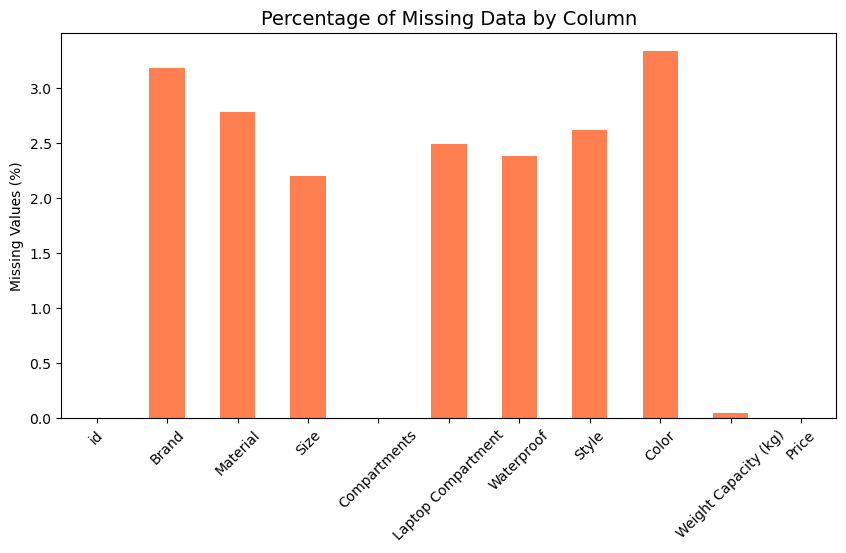

In [15]:

missing_values = extra_df.isnull().mean() * 100

# Plot missing values percentage
plt.figure(figsize=(10, 5))
missing_values.plot(kind="bar", color="coral")
plt.ylabel("Missing Values (%)")
plt.title("Percentage of Missing Data by Column", fontsize=14)
plt.xticks(rotation=45)
plt.show()


| Column Name               | Non-null Count | Total Rows | Missing % |
|---------------------------|--------------|------------|-----------|
| **Brand**                 | 1,015,277   | 1,048,575  | **3.19%** |
| **Material**              | 1,019,399   | 1,048,575  | **2.78%** |
| **Size**                  | 1,025,536   | 1,048,575  | **2.19%** |
| **Compartments**          | 1,048,575   | 1,048,575  | **0%** (No missing data) |
| **Laptop Compartment**    | 1,022,505   | 1,048,575  | **2.49%** |
| **Waterproof**            | 1,023,629   | 1,048,575  | **2.38%** |
| **Style**                 | 1,021,120   | 1,048,575  | **2.62%** |
| **Color**                 | 1,013,630   | 1,048,575  | **3.34%** |
| **Weight Capacity (kg)**  | 1,048,113   | 1,048,575  | **0.04%** |
| **Price**                 | 1,048,575   | 1,048,575  | **0%** (No missing data) |


Low missing percentages (<5%): Impute, because dropping them would remove a lot of data unnecessarily.
High missing percentages (>50%): Drop, but none of your columns have such high missing rates.
Key columns (e.g., Price, Compartments, Weight Capacity) have almost no missing values, so there's no reason to drop them.

In [16]:
extra_df.dropna(inplace=True)
extra_df.shape

(862867, 11)

In [17]:
extra_df.describe().round(2)

,id,Compartments,Weight Capacity (kg),Price
count,862867.00,862867.00,862867.00,862867.00
mean,1024354.09,5.44,18.00,81.49
std,302624.94,2.89,6.97,38.81
min,500000.00,1.00,5.00,15.00
25%,762285.00,3.00,12.06,47.83
50%,1024396.00,5.00,18.04,81.18
75%,1286478.50,8.00,23.98,114.80
max,1548574.00,10.00,30.00,150.00


In [18]:
extra_df.duplicated().sum()

0

In [19]:
test_df.head(3)

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,300000,Puma,Leather,Small,2,No,No,Tote,Green,20.671147
1,300001,Nike,Canvas,Medium,7,No,Yes,Backpack,Green,13.564105
2,300002,Adidas,Canvas,Large,9,No,Yes,Messenger,Blue,11.809799


In [20]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    200000 non-null  int64  
 1   Brand                 193773 non-null  object 
 2   Material              194387 non-null  object 
 3   Size                  195619 non-null  object 
 4   Compartments          200000 non-null  int64  
 5   Laptop Compartment    195038 non-null  object 
 6   Waterproof            195189 non-null  object 
 7   Style                 194847 non-null  object 
 8   Color                 193215 non-null  object 
 9   Weight Capacity (kg)  199923 non-null  float64
dtypes: float64(1), int64(2), object(7)
memory usage: 15.3+ MB


In [21]:
test_df.isna().sum()

id                         0
Brand                   6227
Material                5613
Size                    4381
Compartments               0
Laptop Compartment      4962
Waterproof              4811
Style                   5153
Color                   6785
Weight Capacity (kg)      77
dtype: int64

In [22]:
test_df.duplicated().sum()

0

In [23]:
test_categorical_df = test_df.select_dtypes(include='object')
for col in test_categorical_df.columns:
    test_df[col].fillna(test_df[col].mode()[0], inplace=True)
    
test_numerical_df = test_df.select_dtypes(include=['int64', 'float64'])
for col in test_numerical_df.columns:
    test_df[col].fillna(test_df[col].mean(), inplace=True)
    
test_df.isna().sum()

id                      0
Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
dtype: int64

step 2]. Combining the extra and train data for better prediction

In [24]:
merged_df = pd.concat([train_df, extra_df], ignore_index=True)
merged_df.drop_duplicates(inplace=True)
merged_df = merged_df.drop("id", axis=1)
merged_df.shape

(1162867, 10)

In [25]:
merged_df.head()

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Leather,Medium,7,Yes,No,Tote,Black,11.611723,112.15875
1,Jansport,Canvas,Small,10,Yes,Yes,Messenger,Green,27.078537,68.88056
2,Under Armour,Leather,Small,2,Yes,No,Messenger,Red,16.643760,39.17320
3,Nike,Nylon,Small,8,Yes,No,Messenger,Green,12.937220,80.60793
4,Adidas,Canvas,Medium,1,Yes,Yes,Messenger,Green,17.749338,86.02312


In [26]:
merged_df.nunique()

Brand                        5
Material                     4
Size                         3
Compartments                10
Laptop Compartment           2
Waterproof                   2
Style                        3
Color                        6
Weight Capacity (kg)    522286
Price                    48358
dtype: int64

In [27]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1162867 entries, 0 to 1162866
Data columns (total 10 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Brand                 1162867 non-null  object 
 1   Material              1162867 non-null  object 
 2   Size                  1162867 non-null  object 
 3   Compartments          1162867 non-null  int64  
 4   Laptop Compartment    1162867 non-null  object 
 5   Waterproof            1162867 non-null  object 
 6   Style                 1162867 non-null  object 
 7   Color                 1162867 non-null  object 
 8   Weight Capacity (kg)  1162867 non-null  float64
 9   Price                 1162867 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 88.7+ MB


In [28]:
merged_df.describe().round(2)

,Compartments,Weight Capacity (kg),Price
count,1162867.00,1162867.00,1162867.00
mean,5.44,18.01,81.47
std,2.89,6.97,38.87
min,1.00,5.00,15.00
25%,3.00,12.07,47.72
50%,5.00,18.05,81.12
75%,8.00,23.99,114.84
max,10.00,30.00,150.00


In [29]:
merged_cat_columns = merged_df.select_dtypes(include='object').columns
merged_num_columns = merged_df.select_dtypes(include=['int64', 'float64']).columns
merged_num_columns.value_counts()

Compartments            1
Weight Capacity (kg)    1
Price                   1
Name: count, dtype: int64

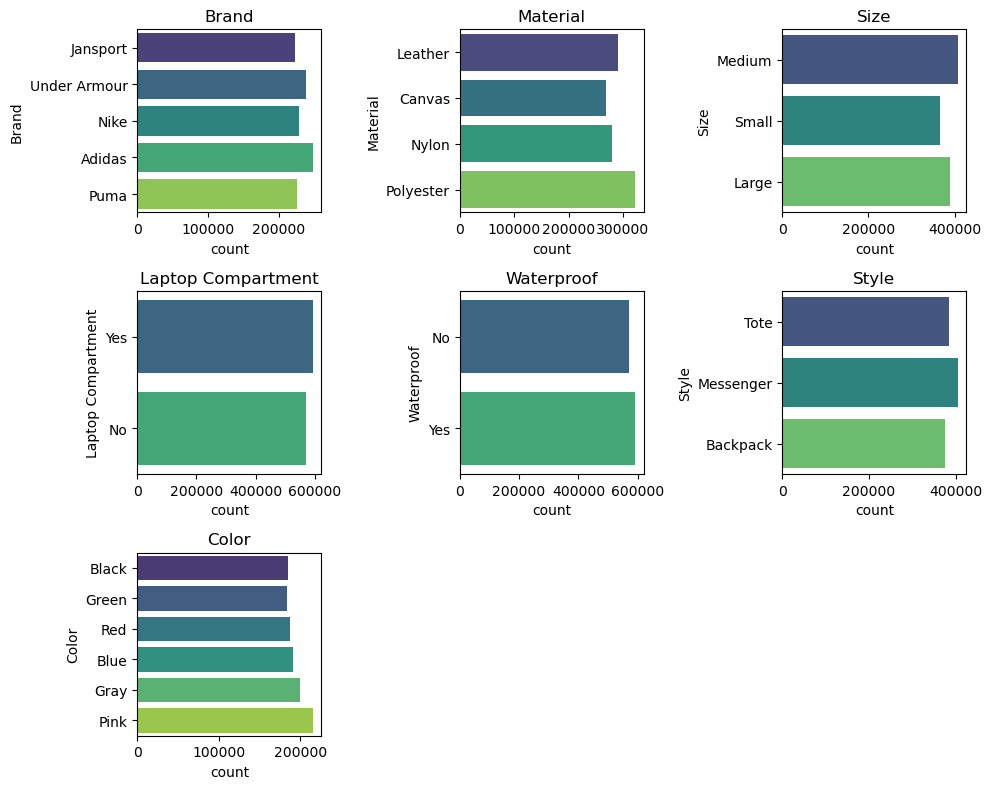

In [30]:
plt.figure(figsize=(10,8))
for i ,col in enumerate(merged_cat_columns ,1):
    plt.subplot(3,3,i)
    sns.countplot(y=col, data=merged_df, palette='viridis')
    plt.title(col)
    
plt.tight_layout()
plt.show()

Brand Distribution:

The distribution of brands appears fairly balanced, with Adidas having the highest count, followed closely by Under Armour, Nike, Puma, and Jansport.
There is no extreme skewness, indicating a good variety of brands.
Material Distribution:

Polyester is the most commonly used material, followed by Leather, Nylon, and Canvas.
Polyester and Leather contribute significantly to the overall count, while Canvas has the lowest count.
Size Distribution:

Medium-sized products dominate, followed by Large and Small.
The distribution suggests that Medium is the most popular or widely available size.
Laptop Compartment Presence:

The number of products with a laptop compartment is slightly higher than those without.
This suggests that having a laptop compartment is a popular feature.
Waterproof Feature Distribution:

The distribution is quite balanced between waterproof and non-waterproof products.
There might be an equal demand for both features.
Style Distribution:

Messenger bags have the highest count, followed by Tote and Backpack styles.
Messenger bags seem to be the most popular style choice.
Color Distribution:

Pink is the most common color, followed by Gray, Blue, Red, Black, and Green.
The differences between color distributions are not very drastic.

In [31]:
merged_df['Weight Capacity (kg)'].value_counts()

Weight Capacity (kg)
5.000000     15101
11.898250      581
14.908437      482
22.898382      468
12.817374      395
             ...  
23.548624        1
16.846992        1
20.356447        1
11.072337        1
6.152840         1
Name: count, Length: 522286, dtype: int64

In [32]:
bins = [0, 5, 10, 15, 20, 50]  
labels = ["Very Low", "Low", "Medium", "High", "Very High"] 
merged_df["Weight_Capacity_Binned"] = pd.cut(merged_df["Weight Capacity (kg)"], bins=bins, labels=labels)
print(merged_df[["Weight Capacity (kg)", "Weight_Capacity_Binned"]].head()) 

   Weight Capacity (kg) Weight_Capacity_Binned
0             11.611723                 Medium
1             27.078537              Very High
2             16.643760                   High
3             12.937220                 Medium
4             17.749338                   High


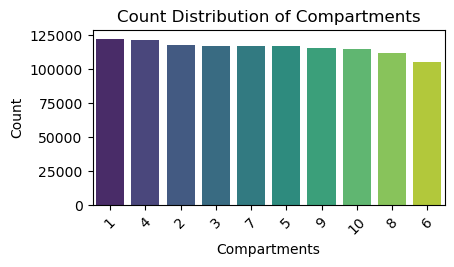

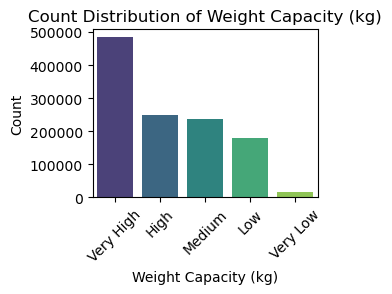

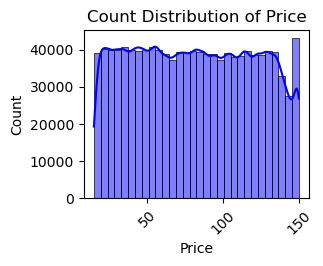

In [33]:
plt.figure(figsize=(10,5))
for i ,col in enumerate(merged_num_columns ,1):
    plt.subplot(2,2,i) 
    if col == "Weight Capacity (kg)":
        sns.countplot(
            x=merged_df["Weight_Capacity_Binned"], 
            order=merged_df["Weight_Capacity_Binned"].value_counts().index, 
            palette="viridis"
        )
    elif merged_df[col].nunique() > 30:  # If too many unique values, use histplot
            sns.histplot(merged_df[col], bins=30, kde=True, color="blue")
    else:
        sns.countplot(
            x=merged_df[col], 
            order=merged_df[col].value_counts().index, 
            palette="viridis"
        )

    plt.title(f"Count Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()  # Show only once per iteration


ANOVA (For Statistical Significance) 
Used for the determining the relations b/w categorical and numurical target val


[p-value < 0.05 → The feature has a significant impact on Price.]

[p-value > 0.05 → No strong relationship with Price]

In [34]:
from scipy.stats import f_oneway

for col in merged_cat_columns:
    groups = [merged_df[merged_df[col] == cat]["Price"] for cat in merged_df[col].unique()]
    if len(groups) > 1:
        stat, p_value = f_oneway(*groups)
        print(f"Feature: {col} | P-value: {p_value}")
    else:
        print(f"Feature: {col} | Not enough groups for ANOVA")

Feature: Brand | P-value: 3.536978681118648e-51
Feature: Material | P-value: 5.643570585907488e-65
Feature: Size | P-value: 1.8772453235909207e-07
Feature: Laptop Compartment | P-value: 0.9720948313731022
Feature: Waterproof | P-value: 0.016810152008871378
Feature: Style | P-value: 0.04391750431571162
Feature: Color | P-value: 4.47000852198385e-81


For Numerical Features (Finding Relation with Price)

👉 Use Pearson correlation if your numerical features (e.g., Weight Capacity (kg), Compartments) have a linear relationship with Price.

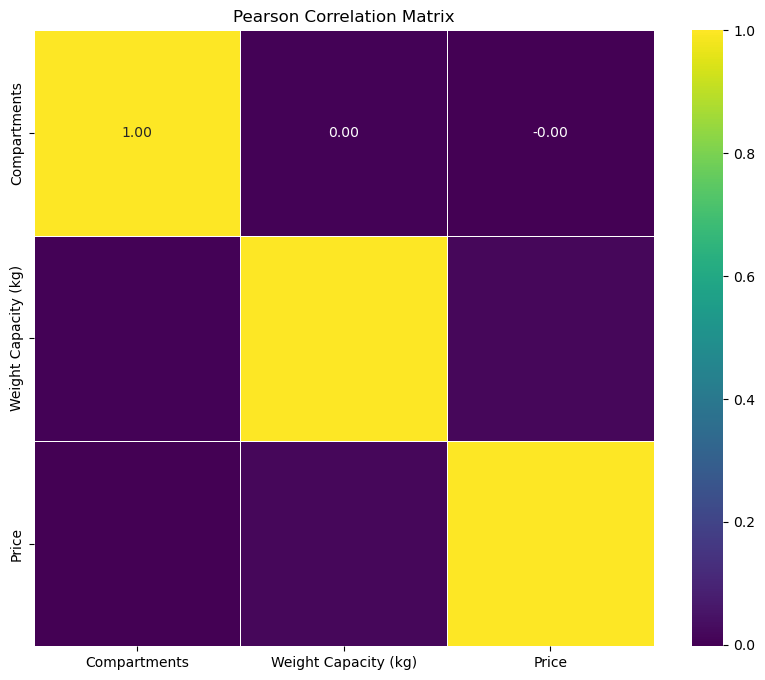

In [35]:
merged_num_df = merged_df.drop(merged_cat_columns, axis=1)
merged_num_df.drop("Weight_Capacity_Binned", axis=1, inplace=True)

corr_matrix = merged_num_df.corr(method="pearson")

    # Visualize as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.show()

In [36]:
# Create a pivot table
pivot_table = merged_df.pivot_table(
    index=["Brand", "Material", "Size"],  # Categorical features for grouping
    values="Price",  # Target column
    aggfunc=["mean", "median", "count", "min", "max", "std"]  # Aggregations
)

# Reset index for better readability
pivot_table = pivot_table.reset_index()

# Display the pivot table
print(pivot_table)


           Brand   Material    Size       mean     median  count   min    max  \
                                         Price      Price  Price Price  Price   
0         Adidas     Canvas   Large  81.464743  81.256730  19549  15.0  150.0   
1         Adidas     Canvas  Medium  80.921789  80.795820  19747  15.0  150.0   
2         Adidas     Canvas   Small  81.183181  80.638070  18488  15.0  150.0   
3         Adidas    Leather   Large  80.179221  78.895170  20798  15.0  150.0   
4         Adidas    Leather  Medium  79.275548  77.655640  21645  15.0  150.0   
5         Adidas    Leather   Small  79.849745  78.664130  19455  15.0  150.0   
6         Adidas      Nylon   Large  79.916504  79.015815  19500  15.0  150.0   
7         Adidas      Nylon  Medium  80.470283  80.112095  20736  15.0  150.0   
8         Adidas      Nylon   Small  80.300683  79.526665  18690  15.0  150.0   
9         Adidas  Polyester   Large  81.239975  80.985920  22755  15.0  150.0   
10        Adidas  Polyester 

1️⃣ Popular Categories Have Higher Counts
Certain brands/materials/colors appear more frequently in the dataset.
Example: Black Leather Bags might have a significantly higher count than other colors/materials.

2️⃣ Price Variation by Brand & Material
Some brands consistently have higher prices, while others target budget-conscious customers.
Example: Premium brands (Nike, Adidas, Puma, etc.) might have higher mean and median prices compared to local brands.
Leather products tend to be more expensive than canvas or synthetic materials.

3️⃣ Price Distribution by Size
Larger bags (L, XL) tend to have higher prices, while smaller sizes (S, M) have lower average prices.
This could be due to additional compartments, more material usage, or brand pricing strategies.

4️⃣ Color Impact on Pricing
Neutral colors (Black, Brown, Grey) might have a higher count due to popularity but may not always have the highest prices.
Unique or limited edition colors (Red, Gold, Custom prints) might be priced higher due to demand or exclusivity.

5️⃣ Standard Deviation Shows Price Consistency
Lower Std Dev (small variation) means the brand/material has consistent pricing across colors and sizes.
Higher Std Dev (large variation) means that the price fluctuates significantly, possibly due to discounts, demand, or special editions.

6️⃣ Outliers in Pricing
The minimum and maximum prices reveal price outliers.
Example: A backpack priced at ₹500 might be an entry-level product, while one priced at ₹10,000+ could be a luxury or premium product.

7️⃣ Luxury vs. Budget Segments
Some brands target high-end customers (high avg price, high min price), while others cater to the mass market (low avg price, low min price).
Example: Nike, Puma, Samsonite might have higher mean and max prices, while local brands have lower ones.

In [37]:

# Group by categorical features and calculate aggregations for 'Price'
grouped_df = merged_df.groupby(["Brand", "Material", "Size","Color"]).agg(
    Price_Mean=("Price", "mean"),
    Price_Median=("Price", "median"),
    Price_Count=("Price", "count"),
    Price_Min=("Price", "min"),
    Price_Max=("Price", "max"),
    Price_Std=("Price", "std")
).reset_index()

# Display the grouped dataframe
print(grouped_df)


            Brand   Material   Size  Color  Price_Mean  Price_Median  \
0          Adidas     Canvas  Large  Black   79.603890     77.722845   
1          Adidas     Canvas  Large   Blue   83.024643     84.617860   
2          Adidas     Canvas  Large   Gray   80.808924     80.281380   
3          Adidas     Canvas  Large  Green   81.729004     81.494250   
4          Adidas     Canvas  Large   Pink   82.723770     83.270820   
..            ...        ...    ...    ...         ...           ...   
355  Under Armour  Polyester  Small   Blue   83.571323     85.612765   
356  Under Armour  Polyester  Small   Gray   81.850096     81.340600   
357  Under Armour  Polyester  Small  Green   84.155472     84.471615   
358  Under Armour  Polyester  Small   Pink   83.684264     84.167120   
359  Under Armour  Polyester  Small    Red   83.855863     85.741800   

     Price_Count  Price_Min  Price_Max  Price_Std  
0           3078       15.0      150.0  39.418306  
1           3157       15.0    

Key Takeaways

✅ Price is relatively stable across all brands, materials, sizes, and colors.

✅ Standard deviation shows moderate variation, but no extreme price outliers.

✅ Material and color do not significantly impact price, while size has a minor effect.

✅ Adidas, Nike, and Under Armour follow a similar pricing strategy.

✅ The $15-$150 range suggests this dataset does not include luxury or high-end products.



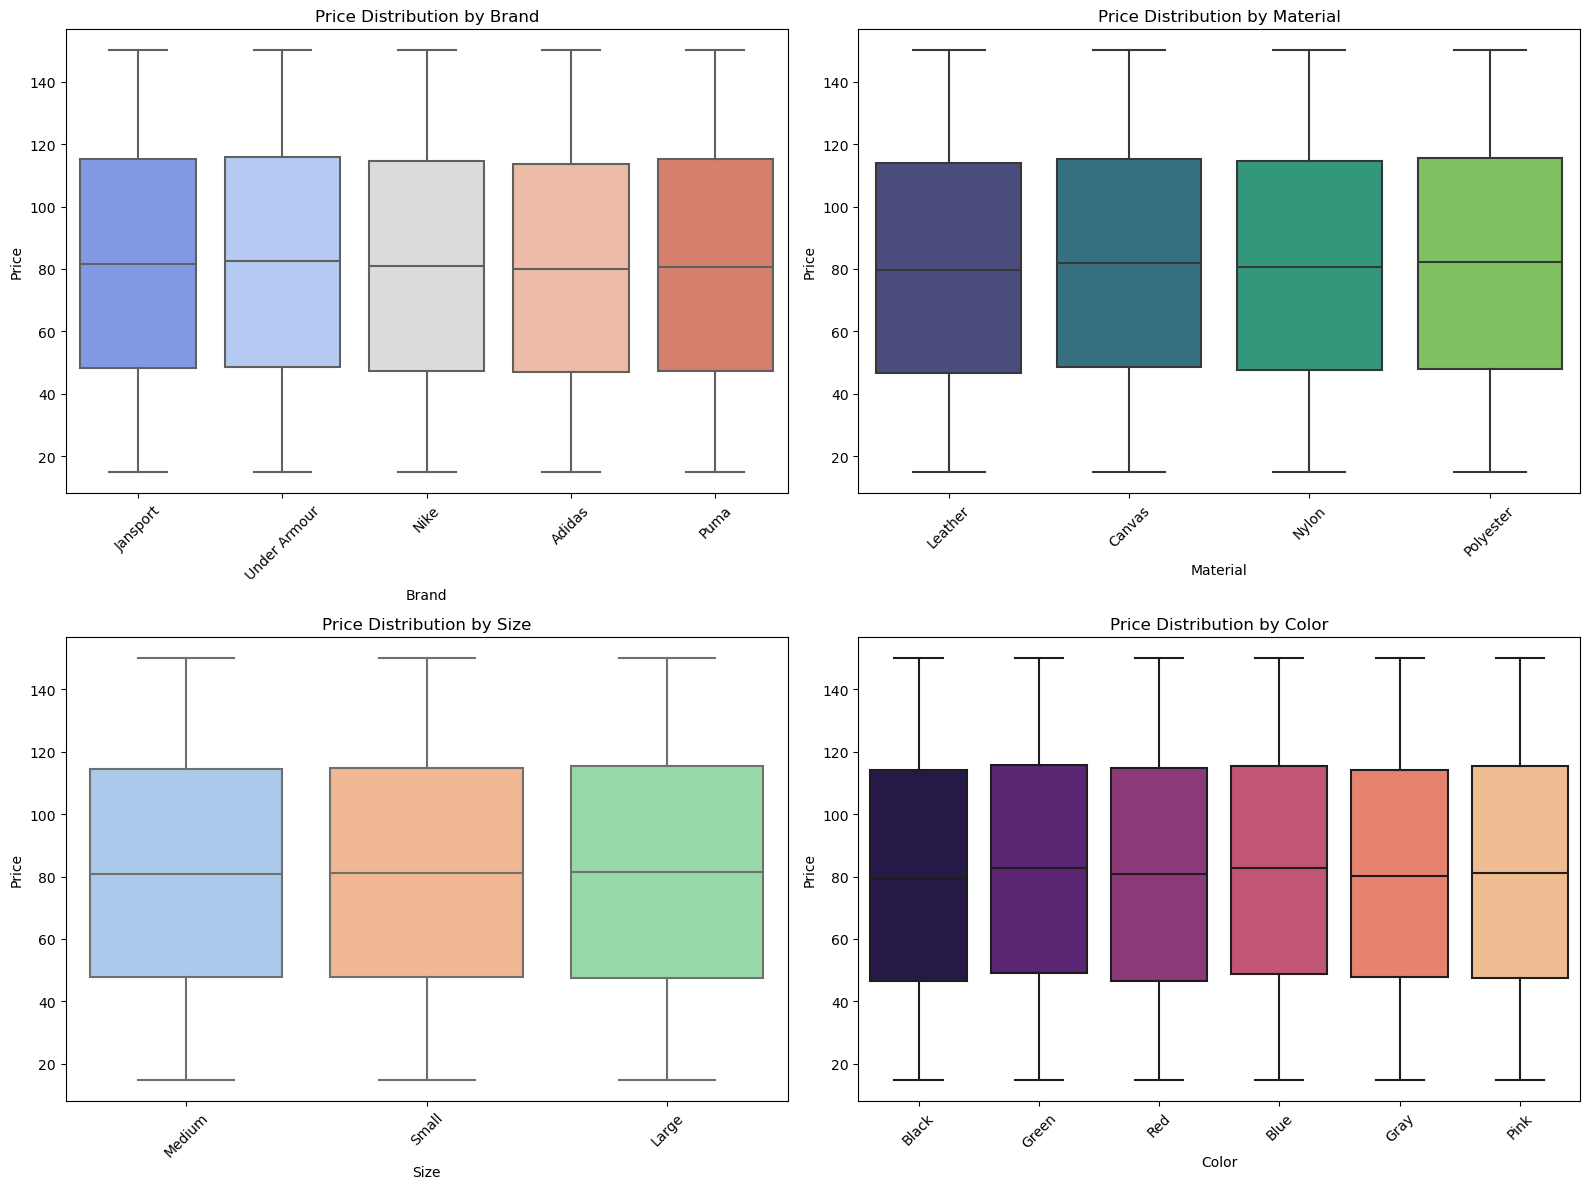

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define categorical columns to plot
categories = ["Brand", "Material", "Size", "Color"]
palettes = ["coolwarm", "viridis", "pastel", "magma"]

# Loop through categories and plot boxplots
for ax, category, palette in zip(axes.flatten(), categories, palettes):
    sns.boxplot(x=category, y="Price", data=merged_df, palette=palette, ax=ax)
    ax.set_title(f"Price Distribution by {category}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()


Key Takeaways 🔍

✅ Brand and Material do not strongly influence price variations.

✅ Bag Size does not significantly impact pricing.

✅ Color has no major impact on price distribution.

✅ A pricing model should focus on other factors like compartments, laptop compatibility, or waterproofing.

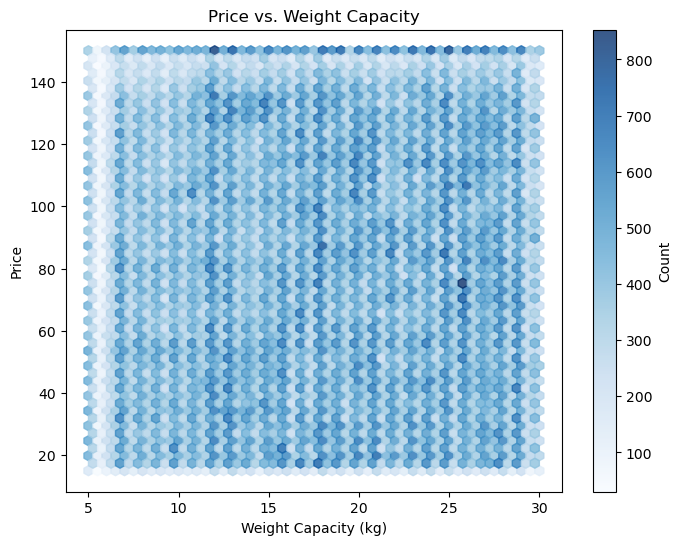

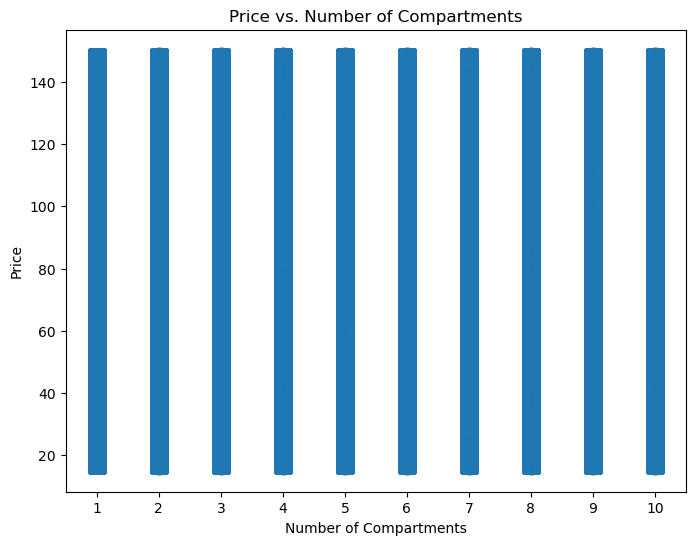

In [39]:
plt.figure(figsize=(8, 6))
plt.hexbin(merged_df["Weight Capacity (kg)"], merged_df["Price"], gridsize=50, cmap="Blues", alpha=0.8)
plt.colorbar(label="Count")
plt.title("Price vs. Weight Capacity")
plt.xlabel("Weight Capacity (kg)")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x="Compartments", y="Price", data=merged_df, alpha=0.2, color="green")
sns.stripplot(x="Compartments", y="Price", data=merged_df, jitter=True, alpha=0.5)
plt.title("Price vs. Number of Compartments")
plt.xlabel("Number of Compartments")
plt.ylabel("Price")
plt.show()


Price vs. Weight Capacity (First Scatter Plot)

The plot appears to be densely packed with blue points, making it hard to distinguish trends.
If points are too close together, consider adding transparency (alpha=0.5) or using a hexbin or density plot to visualize the distribution more clearly.
Check for any potential relationships: Does price increase with weight capacity?


Price vs. Number of Compartments (Second Scatter Plot)

The data points are aligned in vertical lines, suggesting that the number of compartments is categorical or discrete rather than continuous.
Each compartment value has a range of prices, meaning there isn't a strict correlation between compartments and price.
To improve clarity, try adding jitter (slightly adjusting the positions) or using a box plot to show price distribution for each compartment count.

step4] Encoding :-->

In [40]:
merged_df.drop("Weight_Capacity_Binned", axis=1, inplace=True)
# Select categorical columns
merged_cat_df = merged_df[merged_cat_columns]  # Assuming 'merged_cat_columns' contains categorical column names

# Perform one-hot encoding (drop_first=True to avoid multicollinearity)
encoded_df = pd.get_dummies(merged_cat_df, drop_first=True)

# Merge the encoded data back with the original DataFrame (excluding the original categorical columns)
merged_df = pd.concat([merged_df.drop(columns=merged_cat_columns), encoded_df], axis=1)

print("One-hot encoding completed successfully!")


One-hot encoding completed successfully!


In [41]:
test_df.head()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,300000,Puma,Leather,Small,2,No,No,Tote,Green,20.671147
1,300001,Nike,Canvas,Medium,7,No,Yes,Backpack,Green,13.564105
2,300002,Adidas,Canvas,Large,9,No,Yes,Messenger,Blue,11.809799
3,300003,Adidas,Nylon,Large,1,Yes,No,Messenger,Green,18.477036
4,300004,Adidas,Nylon,Large,2,Yes,Yes,Tote,Black,9.907953


In [42]:
test_cat_columns = test_df.select_dtypes(include='object').columns

# Perform one-hot encoding (drop_first=True to avoid multicollinearity)
encoded_df = pd.get_dummies(test_df[test_cat_columns], drop_first=True)

# Merge encoded data back, keeping 'id' and other non-categorical columns
test_df = pd.concat([test_df.drop(columns=test_cat_columns), encoded_df], axis=1)

print("One-hot encoding completed successfully!")

One-hot encoding completed successfully!


In [43]:
merged_df.to_csv("C:\\Users\\NAMAN\\Desktop\\kaggle_comp\\src\\notebooks\\data\\train_cleaned.csv", index=False)
print("Training data saved to train_cleaned.csv")
test_df.to_csv("C:\\Users\\NAMAN\\Desktop\\kaggle_comp\\src\\notebooks\\data\\test_cleaned.csv", index=False)


Training data saved to train_cleaned.csv
